Traffic Dataset
          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  

Fuel Consumption Dataset
   vehicle_id  year        make               model  \
0       26587  1984  Alfa Romeo           GT V6 2.5   
1       27705  1984  Alfa Romeo           GT V6 2.5   
2       26561  1984  Alfa Romeo  Spider Veloce 2000   
3       27681  1984  Alfa Romeo  Spider Veloce 2000   
4       27

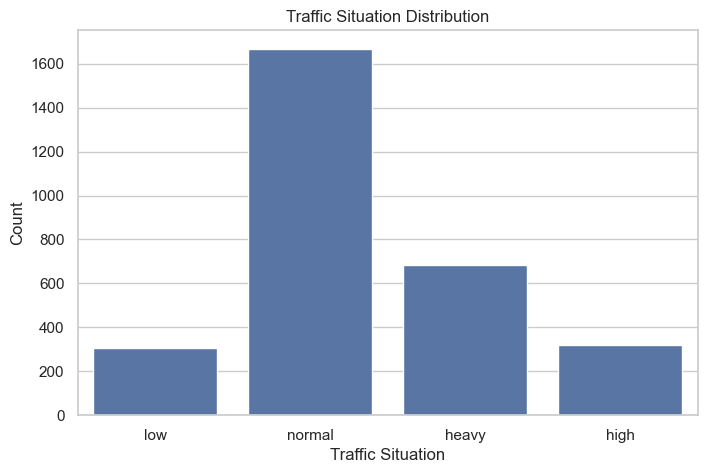

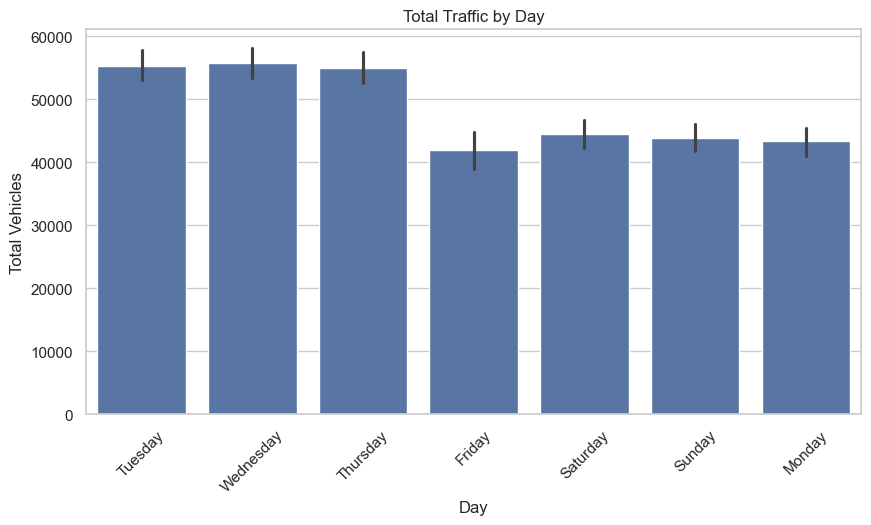

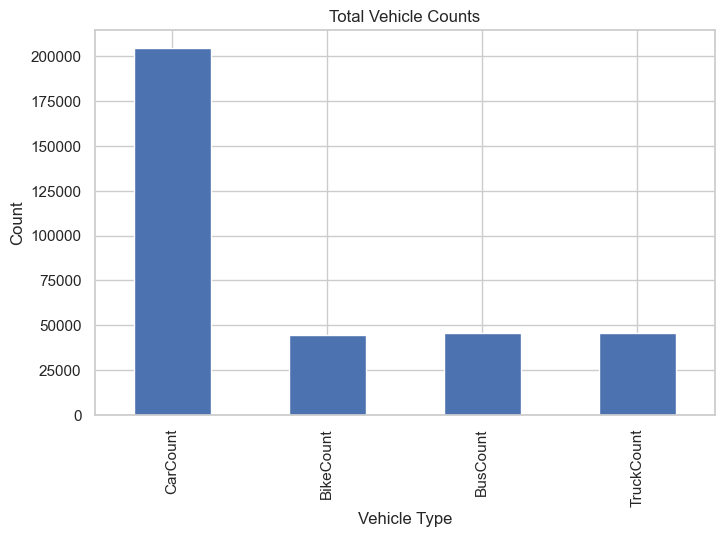

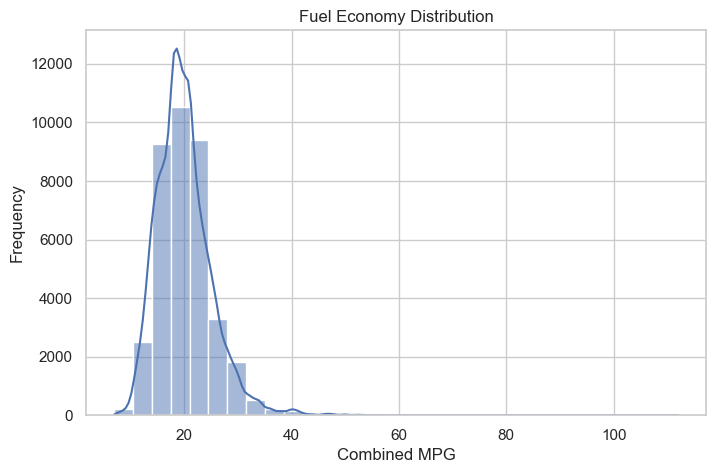

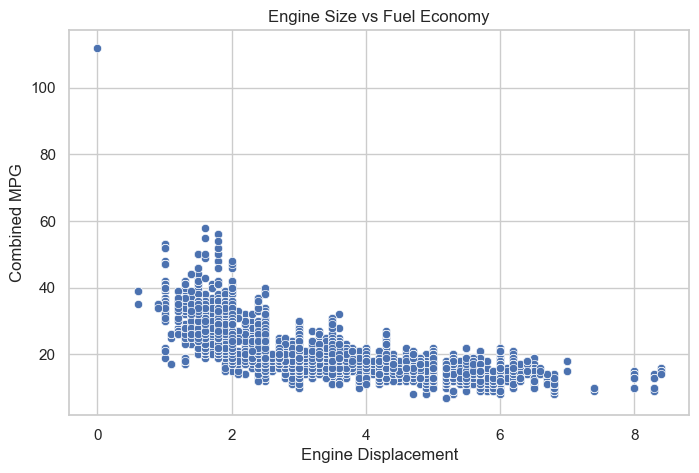

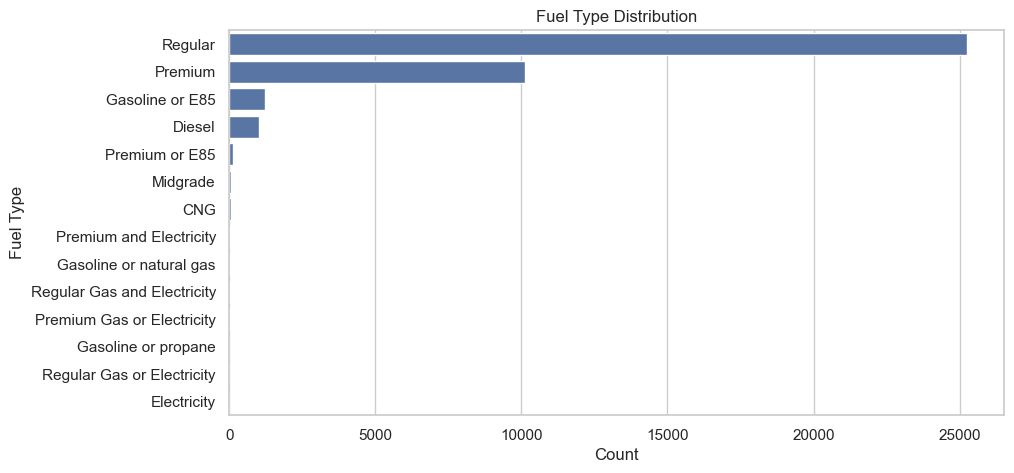

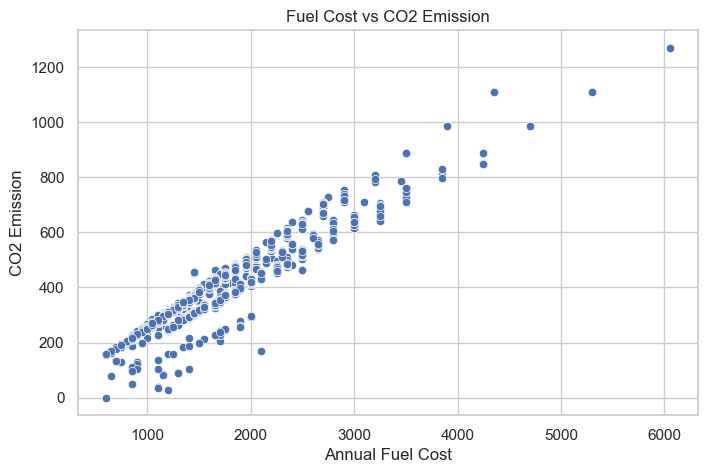

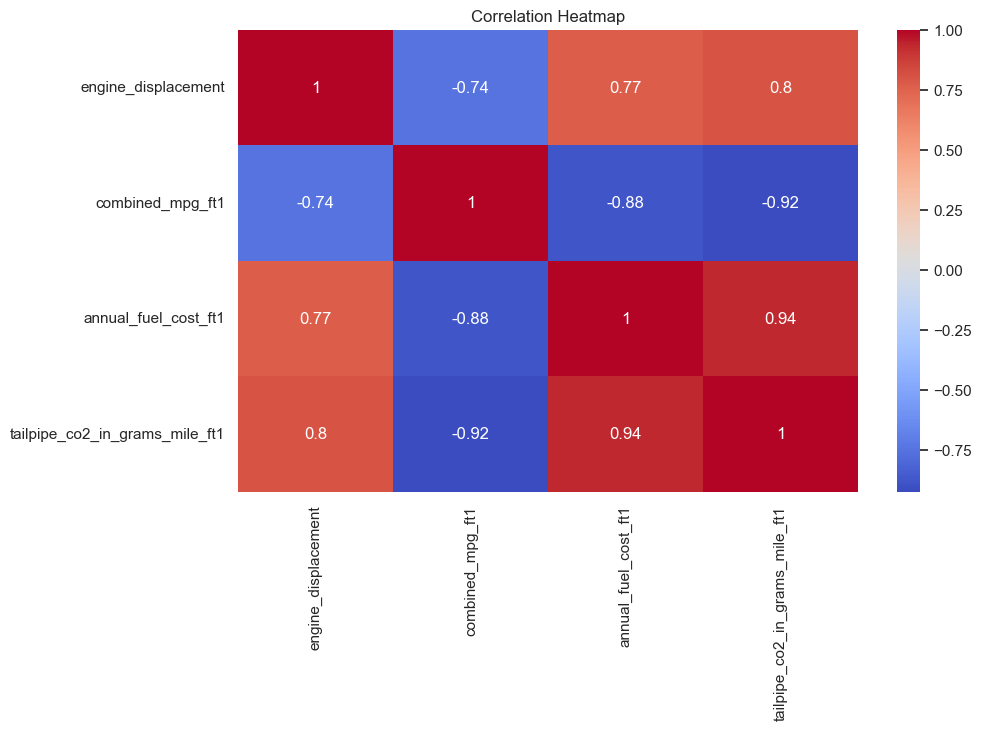

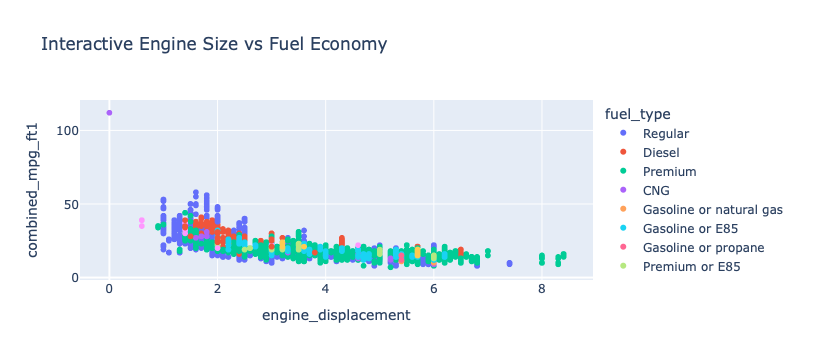

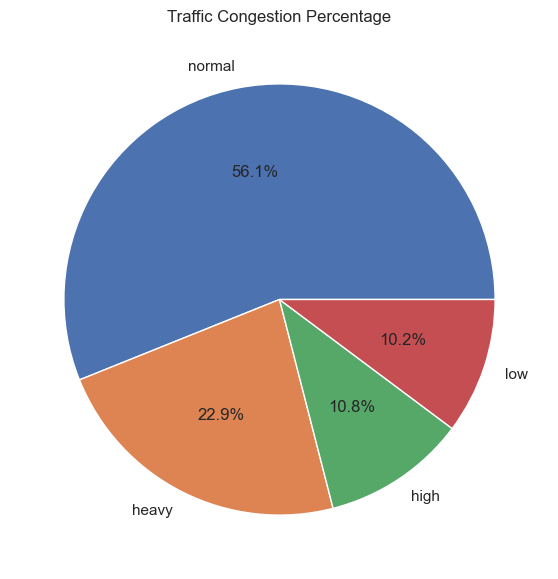


PROJECT CONCLUSION
1. Heavy traffic congestion increases overall fuel consumption.
2. Vehicles with larger engines generally show lower fuel efficiency.
3. Higher fuel costs are associated with higher CO2 emissions.
4. Traffic density significantly affects transportation efficiency.


In [1]:
# =========================================================
# FUEL CONSUMPTION ANALYSIS DUE TO TRAFFIC CONGESTION
# Using:
# 1. vehicle_fuel_consumption.csv
# 2. Traffic.csv
# =========================================================

# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

# -----------------------------
# STEP 2: LOAD DATASETS
# -----------------------------

traffic_df = pd.read_csv("Traffic.csv")
fuel_df = pd.read_csv("vehicle_fuel_consumption.csv", low_memory=False)

# -----------------------------
# STEP 3: DISPLAY DATA
# -----------------------------

print("Traffic Dataset")
print(traffic_df.head())

print("\nFuel Consumption Dataset")
print(fuel_df.head())

# -----------------------------
# STEP 4: CLEAN REQUIRED COLUMNS
# -----------------------------

# Keep only useful columns from fuel dataset
fuel_data = fuel_df[[
    'make',
    'model',
    'fuel_type',
    'engine_displacement',
    'combined_mpg_ft1',
    'annual_fuel_cost_ft1',
    'tailpipe_co2_in_grams_mile_ft1'
]]

# Remove missing values
fuel_data = fuel_data.dropna()

# -----------------------------
# STEP 5: TRAFFIC DATA ANALYSIS
# -----------------------------

print("\nTraffic Dataset Info")
print(traffic_df.info())

print("\nFuel Dataset Info")
print(fuel_data.info())

# =========================================================
# VISUALIZATION 1
# Traffic Situation Count
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Traffic Situation',
    data=traffic_df
)

plt.title("Traffic Situation Distribution")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")

plt.show()

# =========================================================
# VISUALIZATION 2
# Total Traffic by Day
# =========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    x='Day of the week',
    y='Total',
    data=traffic_df,
    estimator=sum
)

plt.title("Total Traffic by Day")
plt.xlabel("Day")
plt.ylabel("Total Vehicles")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# VISUALIZATION 3
# Vehicle Counts Comparison
# =========================================================

vehicle_counts = traffic_df[[
    'CarCount',
    'BikeCount',
    'BusCount',
    'TruckCount'
]].sum()

plt.figure(figsize=(8,5))

vehicle_counts.plot(kind='bar')

plt.title("Total Vehicle Counts")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")

plt.show()

# =========================================================
# VISUALIZATION 4
# Fuel Economy Distribution
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    fuel_data['combined_mpg_ft1'],
    bins=30,
    kde=True
)

plt.title("Fuel Economy Distribution")
plt.xlabel("Combined MPG")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# VISUALIZATION 5
# Engine Size vs Fuel Economy
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='engine_displacement',
    y='combined_mpg_ft1',
    data=fuel_data
)

plt.title("Engine Size vs Fuel Economy")
plt.xlabel("Engine Displacement")
plt.ylabel("Combined MPG")

plt.show()

# =========================================================
# VISUALIZATION 6
# Fuel Type Distribution
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='fuel_type',
    data=fuel_data,
    order=fuel_data['fuel_type'].value_counts().index
)

plt.title("Fuel Type Distribution")
plt.xlabel("Count")
plt.ylabel("Fuel Type")

plt.show()

# =========================================================
# VISUALIZATION 7
# CO2 Emission vs Fuel Cost
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='annual_fuel_cost_ft1',
    y='tailpipe_co2_in_grams_mile_ft1',
    data=fuel_data
)

plt.title("Fuel Cost vs CO2 Emission")
plt.xlabel("Annual Fuel Cost")
plt.ylabel("CO2 Emission")

plt.show()

# =========================================================
# VISUALIZATION 8
# Correlation Heatmap
# =========================================================

numeric_data = fuel_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# VISUALIZATION 9
# Interactive Plotly Chart
# =========================================================

fig = px.scatter(
    fuel_data,
    x='engine_displacement',
    y='combined_mpg_ft1',
    color='fuel_type',
    hover_data=['make', 'model'],
    title='Interactive Engine Size vs Fuel Economy'
)

fig.show()

# =========================================================
# VISUALIZATION 10
# Traffic Congestion Pie Chart
# =========================================================

traffic_counts = traffic_df['Traffic Situation'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    traffic_counts,
    labels=traffic_counts.index,
    autopct='%1.1f%%'
)

plt.title("Traffic Congestion Percentage")

plt.show()

# =========================================================
# FINAL ANALYSIS
# =========================================================

print("\nPROJECT CONCLUSION")
print("1. Heavy traffic congestion increases overall fuel consumption.")
print("2. Vehicles with larger engines generally show lower fuel efficiency.")
print("3. Higher fuel costs are associated with higher CO2 emissions.")
print("4. Traffic density significantly affects transportation efficiency.")